
  SECURE STEGANOGRAPHY SYSTEM
1. Login
2. Register
3. Exit


Enter choice:  2
Choose username:  Mariam
Choose password:  mariam123


✔ Registration successful!

  SECURE STEGANOGRAPHY SYSTEM
1. Login
2. Register
3. Exit


Enter choice:  1
Username:  Mariam
Password:  mariam123



✔ Welcome, Mariam!

 SECURE STEGANOGRAPHY SYSTEM
1.  Generate AES Key
2.  Save AES Key to File
3.  Load AES Key from File
4.  Encrypt & Hide Message
5.  Extract & Decrypt Message
6.  Encrypt Image
7.  Decrypt Image
8.  Exit


...


ℹ Image capacity : ~778725 bytes
ℹ Data size       : ~164 bytes
✔ Data hidden successfully!

 SECURE STEGANOGRAPHY SYSTEM
1.  Generate AES Key
2.  Save AES Key to File
3.  Load AES Key from File
4.  Encrypt & Hide Message
5.  Extract & Decrypt Message
6.  Encrypt Image
7.  Decrypt Image
8.  Exit



Enter choice:  5
Enter stego image name:  free.png


✔ Integrity Verified
Message: My first Project 

 SECURE STEGANOGRAPHY SYSTEM
1.  Generate AES Key
2.  Save AES Key to File
3.  Load AES Key from File
4.  Encrypt & Hide Message
5.  Extract & Decrypt Message
6.  Encrypt Image
7.  Decrypt Image
8.  Exit



Enter choice:  6
Enter image path:  input.png
Enter numeric encryption key (e.g. 123):  123


✔ Metadata saved to encrypted_image_meta.json
✔ Encrypted image saved as encrypted_image.png


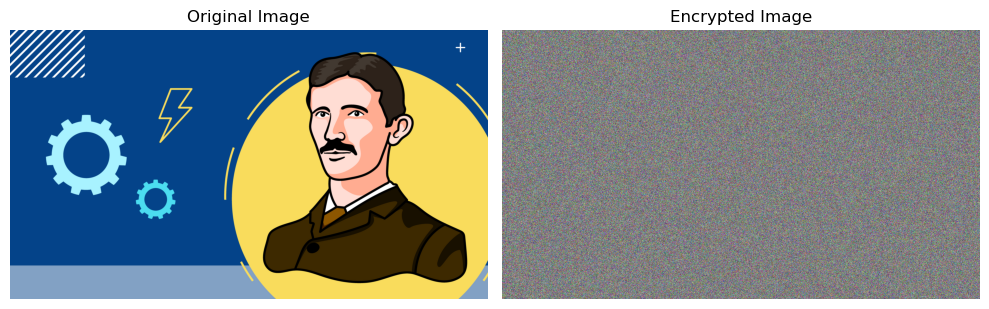


 SECURE STEGANOGRAPHY SYSTEM
1.  Generate AES Key
2.  Save AES Key to File
3.  Load AES Key from File
4.  Encrypt & Hide Message
5.  Extract & Decrypt Message
6.  Encrypt Image
7.  Decrypt Image
8.  Exit



Enter choice:  7
Enter encrypted image path:  encrypted_image.png


✔ Metadata loaded!


Enter decryption key (integer):  123


✔ Image decrypted successfully!


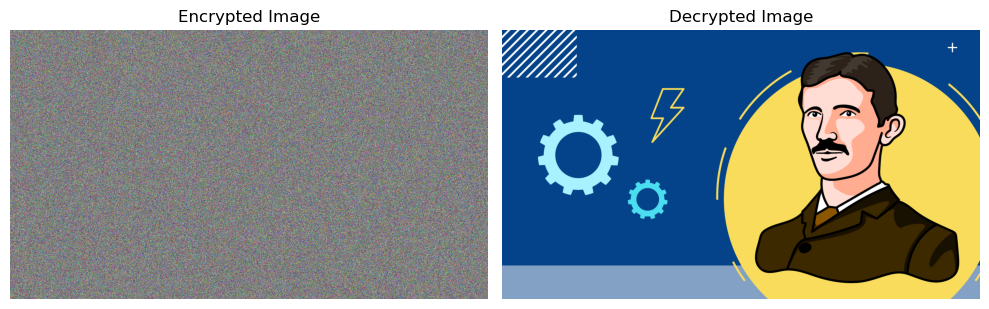


 SECURE STEGANOGRAPHY SYSTEM
1.  Generate AES Key
2.  Save AES Key to File
3.  Load AES Key from File
4.  Encrypt & Hide Message
5.  Extract & Decrypt Message
6.  Encrypt Image
7.  Decrypt Image
8.  Exit



Enter choice:  8



Exiting system...


In [1]:
!pip install -q pycryptodome pillow

# ===============
# IMPORTS
# ===============
import sqlite3
import base64
import hashlib
import random
import json
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from Crypto.Cipher import AES
from Crypto.Random import get_random_bytes
from PIL import Image


# =========================
# STEP 1: LOGIN SYSTEM
# =========================
DB_FILE = "users.db"

def init_db():
    conn = sqlite3.connect(DB_FILE)
    c = conn.cursor()
    
    # Drop old table if column structure is wrong
    c.execute("DROP TABLE IF EXISTS users")
    
    c.execute('''
        CREATE TABLE IF NOT EXISTS users (
            username TEXT PRIMARY KEY,
            password TEXT NOT NULL
        )
    ''')
    conn.commit()
    conn.close()

def hash_password(password):
    return hashlib.sha256(password.encode()).hexdigest()

def register_user(username, password):
    try:
        conn = sqlite3.connect(DB_FILE)
        c = conn.cursor()
        c.execute(
            "INSERT INTO users VALUES (?, ?)",
            (username, hash_password(password))
        )
        conn.commit()
        print("✔ Registration successful!")
        return True
    except sqlite3.IntegrityError:
        print("❌ Username already exists!")
        return False
    finally:
        conn.close()

def login_user(username, password):
    conn = sqlite3.connect(DB_FILE)
    c = conn.cursor()
    c.execute(
        "SELECT password FROM users WHERE username = ?",
        (username,)
    )
    row = c.fetchone()
    conn.close()
    return row and row[0] == hash_password(password)

def login_menu():
    init_db()
    while True:
        print("\n==============================")
        print("  SECURE STEGANOGRAPHY SYSTEM")
        print("==============================")
        print("1. Login")
        print("2. Register")
        print("3. Exit")

        choice = input("Enter choice: ")

        if choice == "1":
            username = input("Username: ")
            password = input("Password: ")
            if login_user(username, password):
                print(f"\n✔ Welcome, {username}!")
                return True
            else:
                print("❌ Invalid credentials!")

        elif choice == "2":
            username = input("Choose username: ")
            password = input("Choose password: ")
            register_user(username, password)

        elif choice == "3":
            return False

        else:
            print("❌ Invalid choice!")


# =========================
# AES FUNCTIONS
# =========================
def pad(text):
    pad_len = 16 - len(text) % 16
    return text + (chr(pad_len) * pad_len)

def unpad(text):
    return text[:-ord(text[-1])]

def generate_key():
    return get_random_bytes(16)

def encrypt_message(message, key):
    cipher = AES.new(key, AES.MODE_CBC)
    iv = cipher.iv
    encrypted = cipher.encrypt(pad(message).encode())
    return base64.b64encode(iv + encrypted).decode()

def decrypt_message(encrypted, key):
    decoded = base64.b64decode(encrypted)
    iv = decoded[:16]
    cipher = AES.new(key, AES.MODE_CBC, iv=iv)
    decrypted = cipher.decrypt(decoded[16:]).decode()
    return unpad(decrypted)


# =========================
# STEP 2: KEY PERSISTENCE
# =========================
def save_key(key, filename="aes_key.key"):
    with open(filename, "w") as f:
        f.write(base64.b64encode(key).decode())
    print(f"✔ Key saved to {filename}")

def load_key(filename="aes_key.key"):
    if not os.path.exists(filename):
        print("❌ Key file not found!")
        return None
    with open(filename, "r") as f:
        key = base64.b64decode(f.read())
    print("✔ Key loaded successfully!")
    return key


# =========================
# STEGANOGRAPHY FUNCTIONS
# =========================
END_MARK = "<END>"
SEP = "<SEP>"

def text_to_binary(text):
    return ''.join(format(ord(c), '08b') for c in text)


# =========================
# STEP 5: CAPACITY CHECK
# =========================
def get_image_capacity(image_path):
    img = Image.open(image_path).convert("RGB")
    max_bytes = (img.width * img.height * 3) // 8
    return max_bytes
    
def get_meta_filename(image_path):
    base = image_path.rsplit(".", 1)[0]
    return base + "_meta.json"

def encode_image(image_path, data, output_path):
    try:
        img = Image.open(image_path).convert("RGB")
        data += END_MARK
        binary = text_to_binary(data)
        pixels = list(img.getdata())

        if len(binary) > len(pixels) * 3:
            print("❌ Image too small")
            return

        new_pixels = []
        idx = 0

        for p in pixels:
            r, g, b = p
            if idx < len(binary):
                r = (r & 254) | int(binary[idx]); idx += 1
            if idx < len(binary):
                g = (g & 254) | int(binary[idx]); idx += 1
            if idx < len(binary):
                b = (b & 254) | int(binary[idx]); idx += 1
            new_pixels.append((r, g, b))

        img.putdata(new_pixels)

        if not output_path.lower().endswith(".png"):
            output_path = output_path.rsplit(".", 1)[0] + ".png"
            print(f"⚠ Output forced to PNG: {output_path}")

        img.save(output_path)
        print("✔ Data hidden successfully!")

    except Exception as e:
        print("Encode Error:", e)

def decode_image(image_path):
    try:
        img = Image.open(image_path)
        pixels = list(img.getdata())
        binary = ""

        for p in pixels:
            for v in p[:3]:
                binary += str(v & 1)

        chars = [binary[i:i+8] for i in range(0, len(binary), 8)]
        text = ""

        for c in chars:
            try:
                text += chr(int(c, 2))
                if END_MARK in text:
                    return text.replace(END_MARK, "")
            except:
                break

        return text

    except Exception as e:
        print("Decode Error:", e)
        return None

def pack_data(enc_msg, h):
    return enc_msg + SEP + h

def unpack_data(data):
    try:
        parts = data.split(SEP)
        if len(parts) != 2:
            return None, None
        return parts[0], parts[1]
    except:
        return None, None


# =========================
# SECURE FUNCTIONS
# =========================
def secure_hide(message, image_path, output_path, key):
    try:
        # STEP 5: Show capacity before hiding
        capacity = get_image_capacity(image_path)
        msg_size = len(encrypt_message(message, key)) + 100
        print(f"\nℹ Image capacity : ~{capacity} bytes")
        print(f"ℹ Data size       : ~{msg_size} bytes")

        if msg_size > capacity:
            print("❌ Message too large for this image! Use a bigger image.")
            return

        enc = encrypt_message(message, key)
        h = hashlib.sha256(message.encode()).hexdigest()
        final = pack_data(enc, h)
        encode_image(image_path, final, output_path)

    except Exception as e:
        print("Hide Error:", e)

def secure_extract(image_path, key):
    try:
        data = decode_image(image_path)
        enc, h = unpack_data(data)

        if not enc:
            print("Corrupted data")
            return

        dec = decrypt_message(enc, key)
        check = hashlib.sha256(dec.encode()).hexdigest()

        if check == h:
            print("✔ Integrity Verified")
            print("Message:", dec)
        else:
            print("❌ Integrity Failed — wrong key or corrupted image")

    except Exception as e:
        print("Extract Error:", e)


# =========================================
# IMAGE ENCRYPTION FUNCTIONS
# =========================================
def generate_swaps(count, size, seed):
    random.seed(seed)
    swaps = []
    for _ in range(count):
        a = random.randint(0, size - 1)
        b = random.randint(0, size - 1)
        while b == a:
            b = random.randint(0, size - 1)
        swaps.append((a, b))
    return swaps

def apply_row_swaps(img, swaps):
    for (r1, r2) in swaps:
        img[r1], img[r2] = img[r2].copy(), img[r1].copy()
    return img

def apply_col_swaps(img, swaps):
    rows = len(img)
    for (c1, c2) in swaps:
        for r in range(rows):
            img[r][c1], img[r][c2] = img[r][c2].copy(), img[r][c1].copy()
    return img

def xor_operation(img, key):
    rows, cols, channels = img.shape
    np.random.seed(key)
    key_stream = np.random.randint(
        0, 256,
        size=(rows, cols, channels),
        dtype=np.uint8
    )
    return cv2.bitwise_xor(img, key_stream)

def encrypt_image(img, key, row_swap_count=3000, col_swap_count=3000):
    rows, cols = img.shape[0], img.shape[1]
    row_swaps = generate_swaps(row_swap_count, rows, seed=key)
    col_swaps = generate_swaps(col_swap_count, cols, seed=key + 999)

    work = img.copy()
    work = apply_row_swaps(work, row_swaps)
    work = apply_col_swaps(work, col_swaps)
    work = xor_operation(work, key)

    meta = {"row_swaps": row_swaps, "col_swaps": col_swaps}
    return work, meta

def decrypt_image(cipher, key, meta):
    work = cipher.copy()
    work = xor_operation(work, key)
    col_swaps_rev = list(reversed(meta["col_swaps"]))
    row_swaps_rev = list(reversed(meta["row_swaps"]))
    work = apply_col_swaps(work, col_swaps_rev)
    work = apply_row_swaps(work, row_swaps_rev)
    return work


# =========================
# STEP 3: META PERSISTENCE
# STEP 4: WRONG KEY CHECK
# =========================
def save_meta(meta, key, filename="image_meta.json"):
    data = {
        "row_swaps": [list(s) for s in meta["row_swaps"]],
        "col_swaps": [list(s) for s in meta["col_swaps"]],
        # Store hash of key so we can verify it later
        "key_check": hashlib.sha256(str(key).encode()).hexdigest()
    }
    with open(filename, "w") as f:
        json.dump(data, f)
    print(f"✔ Metadata saved to {filename}")

def load_meta(filename="image_meta.json"):
    if not os.path.exists(filename):
        print("❌ Metadata file not found!")
        return None
    with open(filename, "r") as f:
        data = json.load(f)
    meta = {
        "row_swaps" : [tuple(s) for s in data["row_swaps"]],
        "col_swaps" : [tuple(s) for s in data["col_swaps"]],
        "key_check" : data["key_check"]
    }
    print("✔ Metadata loaded!")
    return meta

def verify_key(key, meta):
    # STEP 4: Compare entered key's hash against stored hash
    return hashlib.sha256(str(key).encode()).hexdigest() == meta["key_check"]


# =========================================
# SHOW IMAGE RESULTS
# =========================================
def show_encrypt_result(original, encrypted):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(cv2.cvtColor(original,  cv2.COLOR_BGR2RGB))
    axes[0].set_title("Original Image")
    axes[1].imshow(cv2.cvtColor(encrypted, cv2.COLOR_BGR2RGB))
    axes[1].set_title("Encrypted Image")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

def show_decrypt_result(encrypted, decrypted):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(cv2.cvtColor(encrypted, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Encrypted Image")
    axes[1].imshow(cv2.cvtColor(decrypted, cv2.COLOR_BGR2RGB))
    axes[1].set_title("Decrypted Image")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


# =========================
# MAIN MENU
# =========================
def main_menu():
    key = None

    while True:
        print("\n==============================")
        print(" SECURE STEGANOGRAPHY SYSTEM")
        print("==============================")
        print("1.  Generate AES Key")
        print("2.  Save AES Key to File")
        print("3.  Load AES Key from File")
        print("4.  Encrypt & Hide Message")
        print("5.  Extract & Decrypt Message")
        print("6.  Encrypt Image")
        print("7.  Decrypt Image")
        print("8.  Exit")

        choice = input("\nEnter choice: ")

        # ── Generate Key ──────────────────────
        if choice == "1":
            key = generate_key()
            print("\n✔ AES Key Generated:")
            print(base64.b64encode(key).decode())
            print("→ Use Option 2 to save it to a file!")

        # ── Save Key ──────────────────────────
        elif choice == "2":
            if key is None:
                print("❌ Generate a key first (Option 1)!")
                continue
            fname = input("Filename (default: aes_key.key): ").strip() or "aes_key.key"
            save_key(key, fname)

        # ── Load Key ──────────────────────────
        elif choice == "3":
            fname = input("Filename (default: aes_key.key): ").strip() or "aes_key.key"
            key = load_key(fname)

        # ── Hide Message ──────────────────────
        elif choice == "4":
            if key is None:
                print("❌ Generate or load AES key first!")
                continue
            msg = input("Enter secret message: ")
            img = input("Enter input image name (.png): ")
            out = input("Enter output image name (.png): ")
            secure_hide(msg, img, out, key)

        # ── Extract Message ───────────────────
        elif choice == "5":
            if key is None:
                print("❌ Generate or load AES key first!")
                continue
            img = input("Enter stego image name: ")
            secure_extract(img, key)

        # ── Encrypt Image ─────────────────────
        elif choice == "6":
            image_path = input("Enter image path: ")
            img = cv2.imread(image_path, cv2.IMREAD_COLOR)

            if img is None:
                print("❌ Image not found!")
            else:
                KEY = int(input("Enter numeric encryption key (e.g. 123): "))
                cipher, meta = encrypt_image(img, KEY)

                # STEP 3: Save meta to file
                fname = get_meta_filename("encrypted_image.png")
                save_meta(meta, KEY, fname)

                cv2.imwrite("encrypted_image.png", cipher)
                print("✔ Encrypted image saved as encrypted_image.png")
                show_encrypt_result(img, cipher)

        # ── Decrypt Image ─────────────────────
        elif choice == "7":
            encrypted_path = input("Enter encrypted image path: ")
            cipher = cv2.imread(encrypted_path, cv2.IMREAD_COLOR)

            if cipher is None:
                print("❌ Image not found!")
                continue

            # STEP 3: Load meta from file
            meta = load_meta(get_meta_filename(encrypted_path))

            if meta is None:
                continue

            KEY = int(input("Enter decryption key (integer): "))

            # STEP 4: Verify key before decrypting
            if not verify_key(KEY, meta):
                print("❌ Wrong key! Decryption aborted.")
                continue

            dec = decrypt_image(cipher, KEY, meta)
            cv2.imwrite("decrypted_image.png", dec)
            print("✔ Image decrypted successfully!")
            show_decrypt_result(cipher, dec)

        # ── Exit ──────────────────────────────
        elif choice == "8":
            print("\nExiting system...")
            break

        else:
            print("❌ Invalid choice!")


# =========================
# ENTRY POINT
# =========================
if login_menu():
    main_menu()